### Importing Libraries 

In [1]:
import pandas as pd
import numpy as np

In [3]:
diabetes = pd.read_csv('diabetes_prediction_dataset.csv')
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
diab_num = diabetes[['age','bmi','HbA1c_level','blood_glucose_level']]
diab_num.describe()

,age,bmi,HbA1c_level,blood_glucose_level
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,27.320767,5.527507,138.058060
std,22.516840,6.636783,1.070672,40.708136
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.630000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,60.000000,29.580000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


In [6]:
def get_unique_values(dataframe,col_list):
    for col in col_list:
        print('Column:',col)
        print('Unique values:',dataframe[col].unique())
        print('\n')

In [7]:
get_unique_values(diabetes,['gender','hypertension','heart_disease','smoking_history','diabetes'])

Column: gender
Unique values: ['Female' 'Male' 'Other']


Column: hypertension
Unique values: [0 1]


Column: heart_disease
Unique values: [1 0]


Column: smoking_history
Unique values: ['never' 'No Info' 'current' 'former' 'ever' 'not current']


Column: diabetes
Unique values: [0 1]




In [8]:
def get_value_counts(dataframe,col_list):
    for col in col_list:
        print(dataframe[col].value_counts())
        print('\n')

In [9]:
get_value_counts(diabetes,['gender','hypertension','heart_disease','smoking_history','diabetes'])

Female    58552
Male      41430
Other        18
Name: gender, dtype: int64


0    92515
1     7485
Name: hypertension, dtype: int64


0    96058
1     3942
Name: heart_disease, dtype: int64


No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: smoking_history, dtype: int64


0    91500
1     8500
Name: diabetes, dtype: int64




In [10]:
diabetes = diabetes[diabetes.gender != 'Other']

In [11]:
diabetes.gender.value_counts()

Female    58552
Male      41430
Name: gender, dtype: int64

In [12]:
diabetes.shape

(99982, 9)

### Exploratory Data Analysis

In [13]:
d_eda = diabetes.copy()

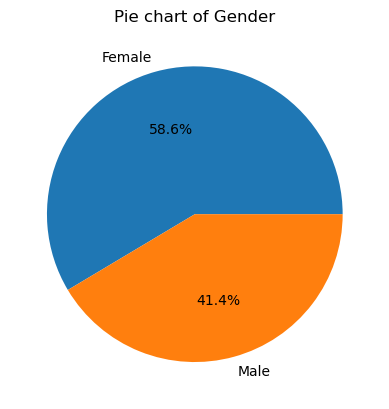

In [14]:
import matplotlib.pyplot as plt

plt.pie(d_eda['gender'].value_counts(),labels=d_eda['gender'].value_counts().index,autopct='%1.1f%%')
plt.title('Pie chart of Gender')
plt.show()

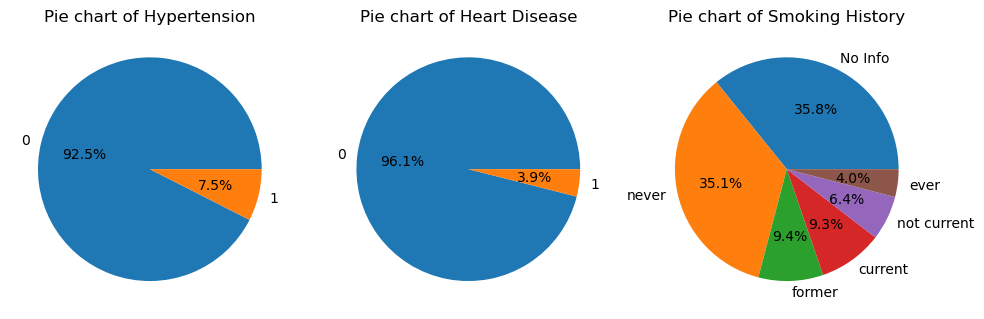

In [15]:
fig,axes = plt.subplots(1,3,figsize=(10,8))
axes[0].pie(d_eda['hypertension'].value_counts(),labels=d_eda['hypertension'].value_counts().index,autopct='%1.1f%%')
axes[0].set_title('Pie chart of Hypertension')
axes[1].pie(d_eda['heart_disease'].value_counts(),labels=d_eda['heart_disease'].value_counts().index,autopct='%1.1f%%')
axes[1].set_title('Pie chart of Heart Disease')
axes[2].pie(d_eda['smoking_history'].value_counts(),labels=d_eda['smoking_history'].value_counts().index,autopct='%1.1f%%')
axes[2].set_title('Pie chart of Smoking History')
plt.tight_layout()
plt.show()

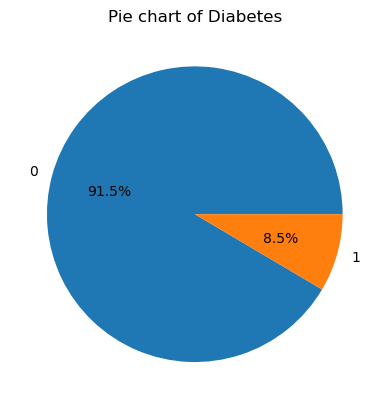

In [16]:
plt.pie(d_eda['diabetes'].value_counts(),labels=d_eda['diabetes'].value_counts().index,autopct='%1.1f%%')
plt.title('Pie chart of Diabetes')
plt.show()

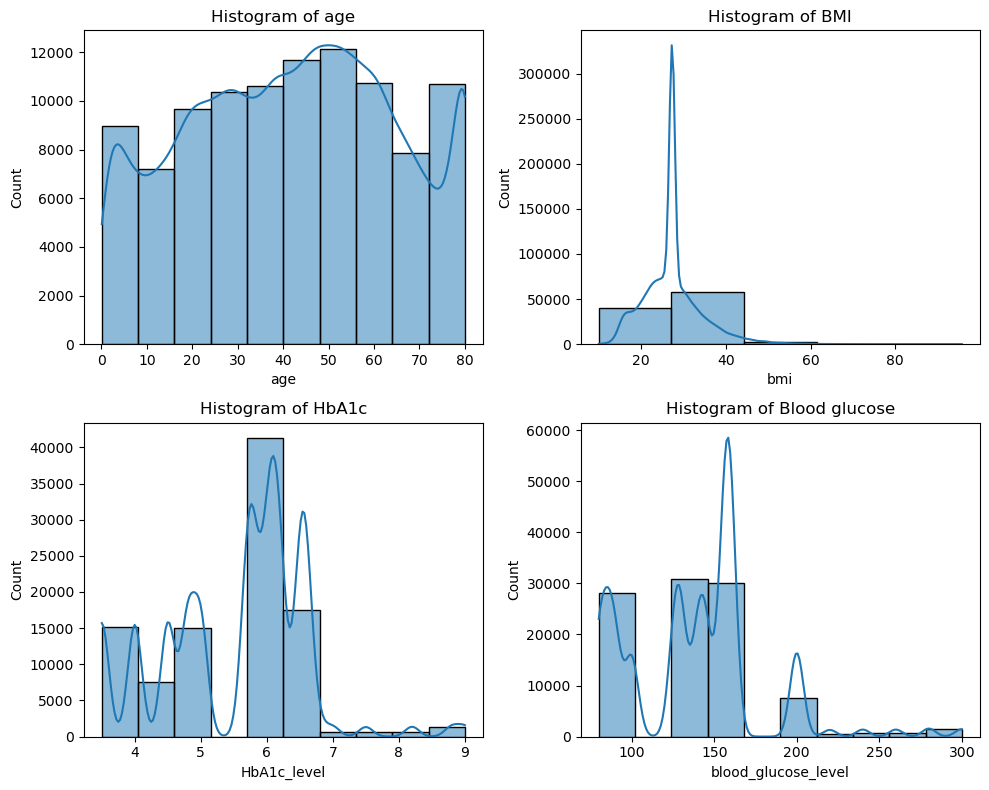

In [17]:
import seaborn as sns

fig,axes = plt.subplots(2,2,figsize=(10,8))
sns.histplot(d_eda['age'],bins=10,kde=True,ax=axes[0,0])
axes[0,0].set_title('Histogram of age')
sns.histplot(d_eda['bmi'],bins=5,kde=True,ax=axes[0,1])
axes[0,1].set_title('Histogram of BMI')
sns.histplot(d_eda['HbA1c_level'],bins=10,kde=True,ax=axes[1,0])
axes[1,0].set_title('Histogram of HbA1c')
sns.histplot(d_eda['blood_glucose_level'],bins=10,kde=True,ax=axes[1,1])
axes[1,1].set_title('Histogram of Blood glucose')
plt.tight_layout()
plt.show()

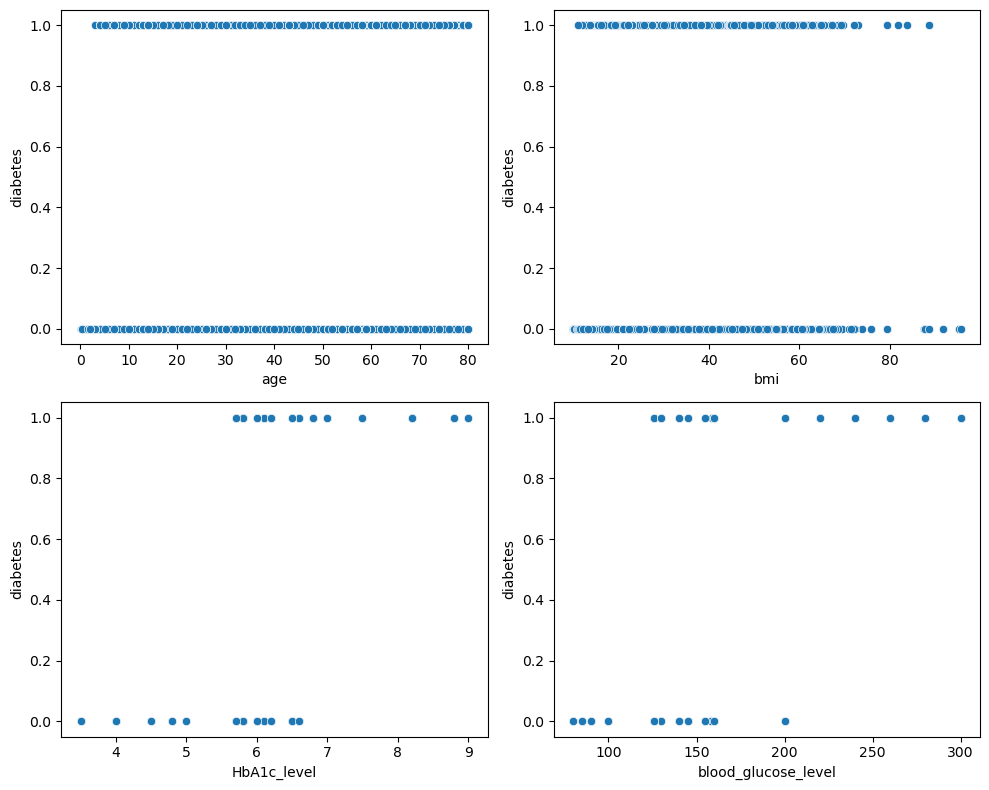

In [18]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
sns.scatterplot(data=d_eda,x='age',y='diabetes',ax=axes[0,0])
sns.scatterplot(data=d_eda,x='bmi',y='diabetes',ax=axes[0,1])
sns.scatterplot(data=d_eda,x='HbA1c_level',y='diabetes',ax=axes[1,0])
sns.scatterplot(data=d_eda,x='blood_glucose_level',y='diabetes',ax=axes[1,1])
plt.tight_layout()
plt.show()

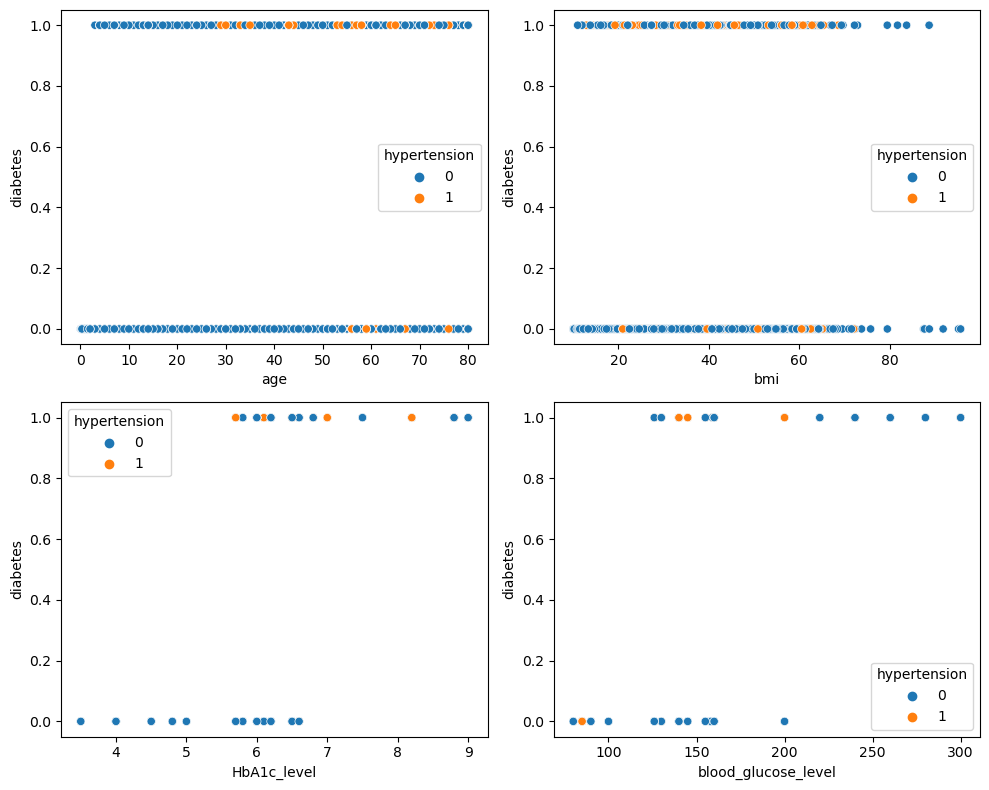

In [19]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
sns.scatterplot(data=d_eda,x='age',y='diabetes',hue=d_eda['hypertension'],ax=axes[0,0])
sns.scatterplot(data=d_eda,x='bmi',y='diabetes',hue=d_eda['hypertension'],ax=axes[0,1])
sns.scatterplot(data=d_eda,x='HbA1c_level',y='diabetes',hue=d_eda['hypertension'],ax=axes[1,0])
sns.scatterplot(data=d_eda,x='blood_glucose_level',y='diabetes',hue=d_eda['hypertension'],ax=axes[1,1])
plt.tight_layout()
plt.show()

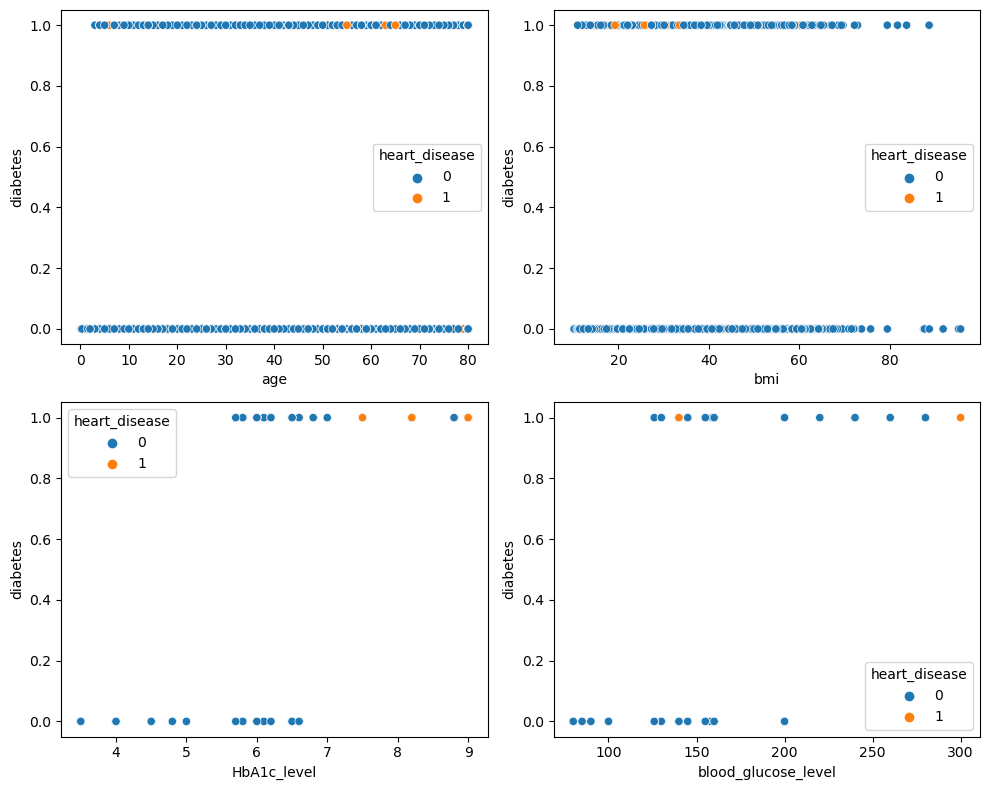

In [20]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
sns.scatterplot(data=d_eda,x='age',y='diabetes',hue=d_eda['heart_disease'],ax=axes[0,0])
sns.scatterplot(data=d_eda,x='bmi',y='diabetes',hue=d_eda['heart_disease'],ax=axes[0,1])
sns.scatterplot(data=d_eda,x='HbA1c_level',y='diabetes',hue=d_eda['heart_disease'],ax=axes[1,0])
sns.scatterplot(data=d_eda,x='blood_glucose_level',y='diabetes',hue=d_eda['heart_disease'],ax=axes[1,1])
plt.tight_layout()
plt.show()

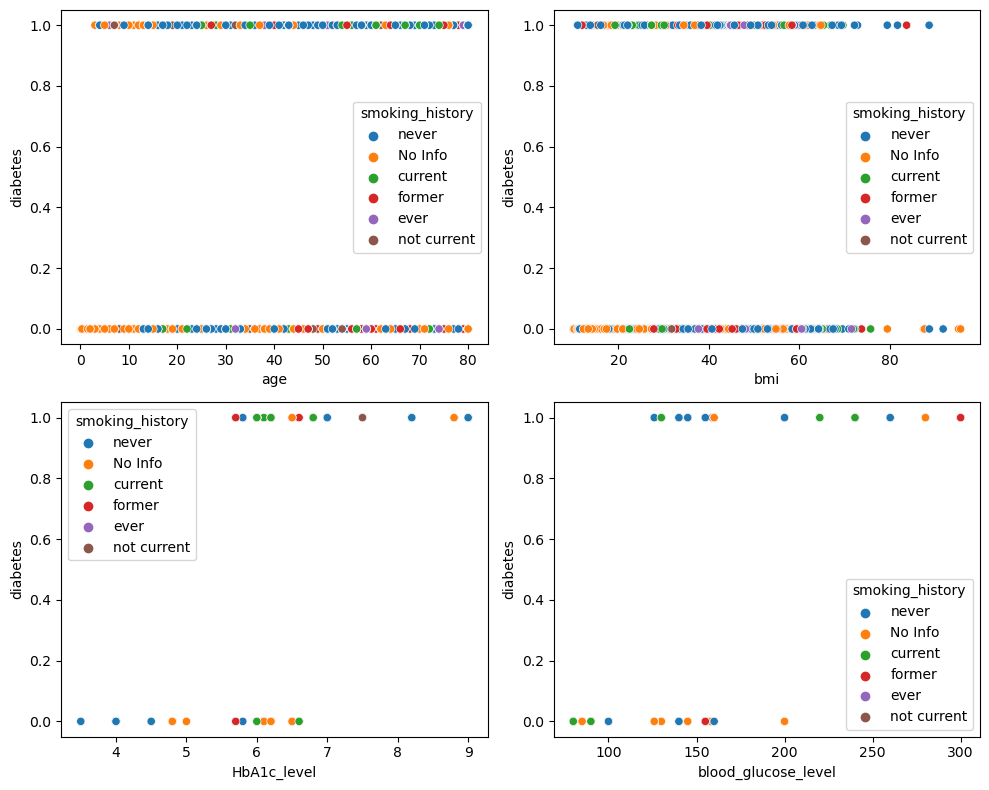

In [21]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
sns.scatterplot(data=d_eda,x='age',y='diabetes',hue=d_eda['smoking_history'],ax=axes[0,0])
sns.scatterplot(data=d_eda,x='bmi',y='diabetes',hue=d_eda['smoking_history'],ax=axes[0,1])
sns.scatterplot(data=d_eda,x='HbA1c_level',y='diabetes',hue=d_eda['smoking_history'],ax=axes[1,0])
sns.scatterplot(data=d_eda,x='blood_glucose_level',y='diabetes',hue=d_eda['smoking_history'],ax=axes[1,1])
plt.tight_layout()
plt.show()

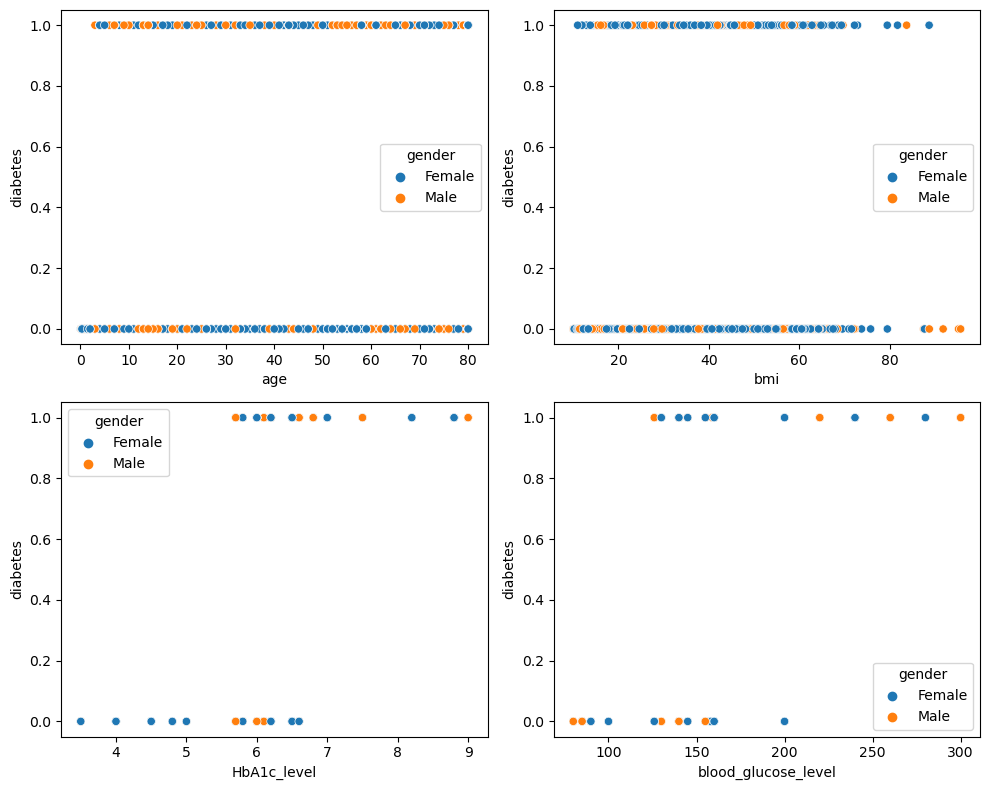

In [22]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
sns.scatterplot(data=d_eda,x='age',y='diabetes',hue=d_eda['gender'],ax=axes[0,0])
sns.scatterplot(data=d_eda,x='bmi',y='diabetes',hue=d_eda['gender'],ax=axes[0,1])
sns.scatterplot(data=d_eda,x='HbA1c_level',y='diabetes',hue=d_eda['gender'],ax=axes[1,0])
sns.scatterplot(data=d_eda,x='blood_glucose_level',y='diabetes',hue=d_eda['gender'],ax=axes[1,1])
plt.tight_layout()
plt.show()

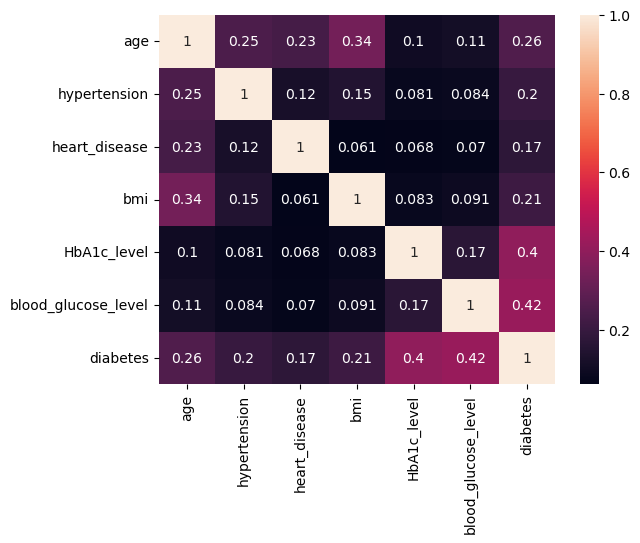

In [23]:
b_num = d_eda.drop(['gender','smoking_history'],axis=1)
corr_diab = b_num.corr()
sns.heatmap(corr_diab,annot=True)
plt.show()

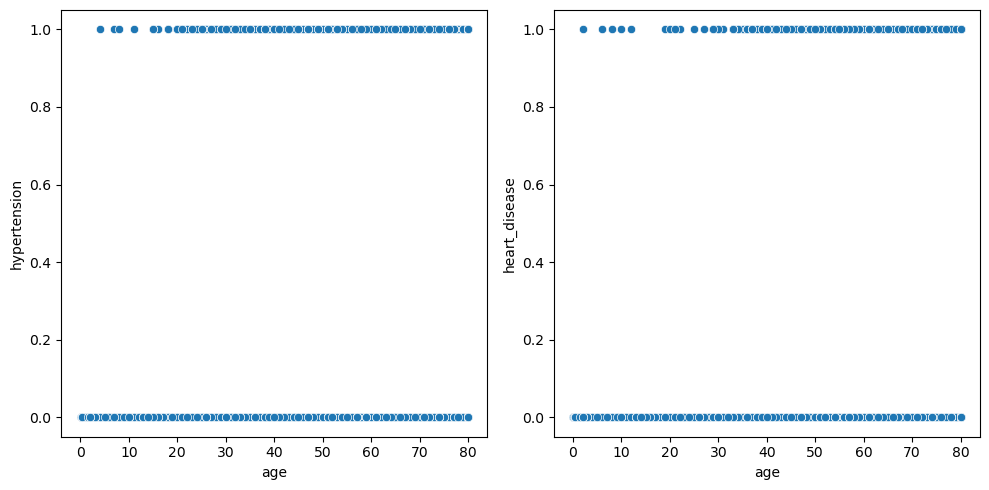

In [24]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
sns.scatterplot(data=d_eda,x='age',y='hypertension',ax=axes[0])
sns.scatterplot(data=d_eda,x='age',y='heart_disease',ax=axes[1])
plt.tight_layout()
plt.show()

In [25]:
gender_g = d_eda.groupby(['gender','diabetes']).size().unstack()
hyper_g = d_eda.groupby(['hypertension','diabetes']).size().unstack()
heart_g = d_eda.groupby(['heart_disease','diabetes']).size().unstack()
smoke_g = d_eda.groupby(['smoking_history','diabetes']).size().unstack()

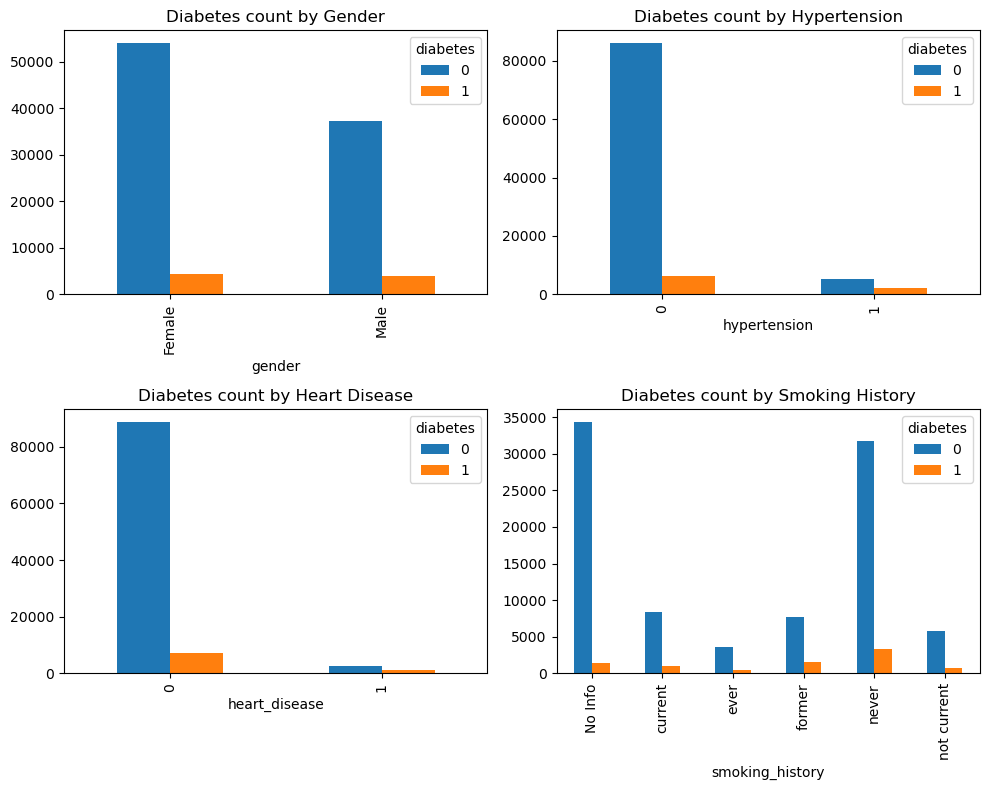

In [26]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
gender_g.plot(kind='bar',ax=axes[0,0])
axes[0,0].set_title('Diabetes count by Gender')
hyper_g.plot(kind='bar',ax=axes[0,1])
axes[0,1].set_title('Diabetes count by Hypertension')
heart_g.plot(kind='bar',ax=axes[1,0])
axes[1,0].set_title('Diabetes count by Heart Disease')
smoke_g.plot(kind='bar',ax=axes[1,1])
axes[1,1].set_title('Diabetes count by Smoking History')
plt.tight_layout()
plt.show()

In [27]:
age_bins = [0,30,60,float('inf')]
age_labels = ['Young','Middle','Old']
glu_bins = [0,140,200,float('inf')]
glu_labels = ['Normal','Medium','High']
hba_bins = [0,5.7,6.4,float('inf')]
hba_labels = ['Normal','Medium','High']
d_eda['age_category'] = pd.cut(d_eda['age'],bins=age_bins,labels=age_labels)
d_eda['glu_category'] = pd.cut(d_eda['blood_glucose_level'],bins=glu_bins,labels=glu_labels)
d_eda['hba_category'] = pd.cut(d_eda['HbA1c_level'],bins=hba_bins,labels=hba_labels)

In [28]:
d_eda.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_category,glu_category,hba_category
0,Female,80.0,0,1,never,25.19,6.6,140,0,Old,Normal,High
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Middle,Normal,High
2,Male,28.0,0,0,never,27.32,5.7,158,0,Young,Medium,Normal
3,Female,36.0,0,0,current,23.45,5.0,155,0,Middle,Medium,Normal
4,Male,76.0,1,1,current,20.14,4.8,155,0,Old,Medium,Normal


In [29]:
d_pos = d_eda[d_eda.diabetes == 1]
d_pos.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_category,glu_category,hba_category
6,Female,44.0,0,0,never,19.31,6.5,200,1,Middle,Medium,High
26,Male,67.0,0,1,not current,27.32,6.5,200,1,Old,Medium,High
38,Male,50.0,1,0,current,27.32,5.7,260,1,Middle,High,Normal
40,Male,73.0,0,0,former,25.91,9.0,160,1,Old,Medium,High
53,Female,53.0,0,0,former,27.32,7.0,159,1,Middle,Medium,High


In [30]:
gender_group = d_pos.groupby(['gender']).size()
age_group = d_pos.groupby(['age_category']).size()
glu_group = d_pos.groupby(['glu_category']).size()
hba_group = d_pos.groupby(['hba_category']).size()

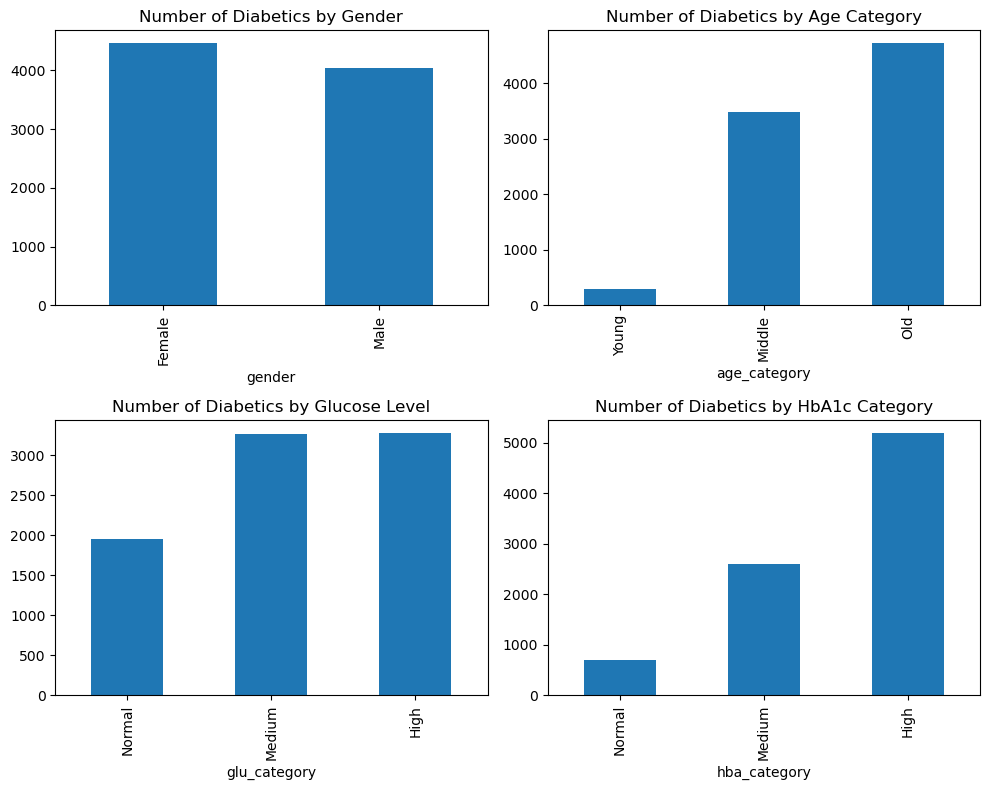

In [31]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
gender_group.plot(kind='bar',ax=axes[0,0])
axes[0,0].set_title('Number of Diabetics by Gender')
age_group.plot(kind='bar',ax=axes[0,1])
axes[0,1].set_title('Number of Diabetics by Age Category')
glu_group.plot(kind='bar',ax=axes[1,0])
axes[1,0].set_title('Number of Diabetics by Glucose Level')
hba_group.plot(kind='bar',ax=axes[1,1])
axes[1,1].set_title('Number of Diabetics by HbA1c Category')
plt.tight_layout()
plt.show()

In [32]:
non_diabetic = d_eda[d_eda.diabetes == 0]
non_diabetic.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_category,glu_category,hba_category
0,Female,80.0,0,1,never,25.19,6.6,140,0,Old,Normal,High
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Middle,Normal,High
2,Male,28.0,0,0,never,27.32,5.7,158,0,Young,Medium,Normal
3,Female,36.0,0,0,current,23.45,5.0,155,0,Middle,Medium,Normal
4,Male,76.0,1,1,current,20.14,4.8,155,0,Old,Medium,Normal


In [33]:
non_gender = non_diabetic.groupby(['gender']).size()
non_age = non_diabetic.groupby(['age_category']).size()
non_glu = non_diabetic.groupby(['glu_category']).size()
non_hba = non_diabetic.groupby(['hba_category']).size()

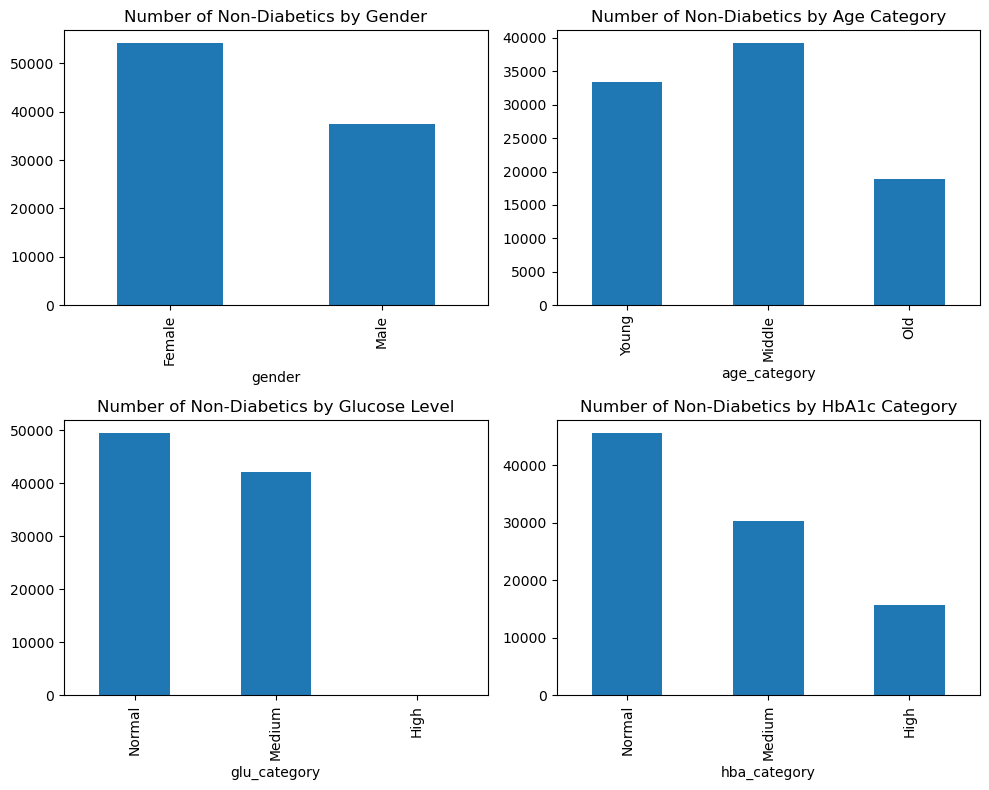

In [34]:
fig,axes = plt.subplots(2,2,figsize=(10,8))
non_gender.plot(kind='bar',ax=axes[0,0])
axes[0,0].set_title('Number of Non-Diabetics by Gender')
non_age.plot(kind='bar',ax=axes[0,1])
axes[0,1].set_title('Number of Non-Diabetics by Age Category')
non_glu.plot(kind='bar',ax=axes[1,0])
axes[1,0].set_title('Number of Non-Diabetics by Glucose Level')
non_hba.plot(kind='bar',ax=axes[1,1])
axes[1,1].set_title('Number of Non-Diabetics by HbA1c Category')
plt.tight_layout()
plt.show()

In [35]:
grouped_diab = d_eda.groupby(['diabetes'])

In [36]:
mean_age = grouped_diab['age'].mean().round()
mean_glu = grouped_diab['blood_glucose_level'].mean().round()
mean_hba1 = grouped_diab['HbA1c_level'].mean().round()
mean_bmi = grouped_diab['bmi'].mean().round()

In [37]:
mean_age.index

Int64Index([0, 1], dtype='int64', name='diabetes')

In [38]:
print('Mean age between Diabetics and Non-Diabetics:',mean_age)
print('Mean glucose level between Diabetics and Non-Diabetics:',mean_glu)
print('Mean HbA1c level between Diabetics and Non-Diabetics:',mean_hba1)
print('Mean BMI between Diabetics and Non-Diabetics:',mean_bmi)

Mean age between Diabetics and Non-Diabetics: diabetes
0    40.0
1    61.0
Name: age, dtype: float64
Mean glucose level between Diabetics and Non-Diabetics: diabetes
0    133.0
1    194.0
Name: blood_glucose_level, dtype: float64
Mean HbA1c level between Diabetics and Non-Diabetics: diabetes
0    5.0
1    7.0
Name: HbA1c_level, dtype: float64
Mean BMI between Diabetics and Non-Diabetics: diabetes
0    27.0
1    32.0
Name: bmi, dtype: float64


### EDA Key Takeaways

1. There are equal number of Male and Female in the dataset.
2. Almost 92% of people do not have Hypertension. Similar values are seen for number of people having heart disease.
3. Number of people having never smoked and those having no information are the largest.
4. Most people are Non-Diabetic. The target class is not balanced.
5. No strong correlations were observed between variables.
6. There is no non-diabetic whose glucose level is greater than 200

### Train Test Split and Data Preprocessing

In [39]:
from sklearn.model_selection import train_test_split

diab_train,diab_test = train_test_split(diabetes,test_size=0.2,stratify = diabetes['diabetes'])

In [40]:
print('Shape of Training set:',diab_train.shape)
print('Shape of Test set:',diab_test.shape)

Shape of Training set: (79985, 9)
Shape of Test set: (19997, 9)


In [41]:
diab_labels = diab_train['diabetes'].copy()
diab_train.drop('diabetes',axis=1,inplace=True)

In [42]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

num_pipeline = make_pipeline(StandardScaler())
cat_pipeline = make_pipeline(OneHotEncoder())
num_attribs = ['age','bmi','HbA1c_level','blood_glucose_level']
cat_attribs = ['gender','hypertension','heart_disease','smoking_history']
preprocessing = ColumnTransformer([
    ('num',num_pipeline,num_attribs),('cat',cat_pipeline,cat_attribs)
])

### Model Selection and Prediction

In [43]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [44]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = make_pipeline(preprocessing,DecisionTreeClassifier(random_state=42))
tree_clf.fit(diab_train,diab_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['gender', 'hypertension',
                                                   'heart_disease',
                                                   'smoking_history'])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [45]:
y_pred_tree = tree_clf.predict(diab_train)
acc_train_tree = accuracy_score(diab_labels,y_pred_tree)
print('Accuracy of Decision Tree Classifier on Train set:',acc_train_tree)

Accuracy of Decision Tree Classifier on Train set: 0.9992373570044384


In [46]:
cross_val_score(tree_clf,diab_train,diab_labels,cv=3,scoring='accuracy')

array([0.94966619, 0.95157903, 0.95221485])

In [47]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = make_pipeline(preprocessing,RandomForestClassifier(random_state=42))
rnd_clf.fit(diab_train,diab_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['gender', 'hypertension',
                                                   'heart_disease',
                                                   'smoking_history'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [48]:
y_pred_rnd = rnd_clf.predict(diab_train)
acc_rnd_train = accuracy_score(diab_labels,y_pred_rnd)
print('Accuracy of Random Forest Classifier on Train:',acc_rnd_train)

Accuracy of Random Forest Classifier on Train: 0.9991873476276802


In [49]:
cross_val_score(rnd_clf,diab_train,diab_labels,cv=3,scoring='accuracy')

array([0.96980722, 0.96976971, 0.97063126])

Model selected - Random Forest Classifier

### Model prediction on Test and Confusion Matrix

In [50]:
test_labels = diab_test['diabetes'].copy()
diab_test.drop('diabetes',axis=1,inplace=True)
y_pred = rnd_clf.predict(diab_test)
acc_test = accuracy_score(test_labels,y_pred)
print('Accuracy score of Random Forest Classifier on Test:',acc_test)

Accuracy score of Random Forest Classifier on Test: 0.9698954843226484


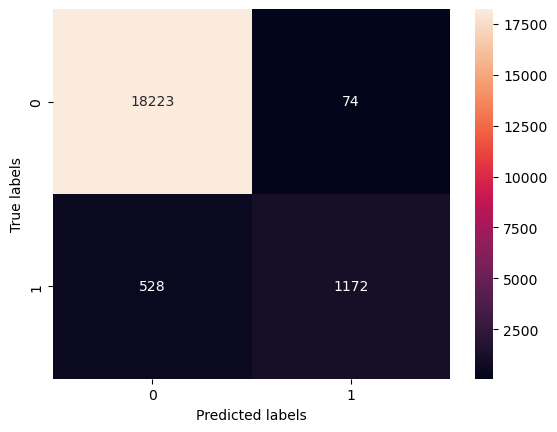

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels,y_pred)
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

The number of non-diabetics predicted as diabetics were very less but the number of diabetics classified as non-diabetics were more indicating high precision and low recall.

In [52]:
from sklearn.metrics import precision_score,recall_score

precision = precision_score(test_labels,y_pred,average='binary')
recall = recall_score(test_labels,y_pred,average='binary')
print('Precision Score:',precision)
print('Recall Score:',recall)

Precision Score: 0.9406099518459069
Recall Score: 0.6894117647058824


In [53]:
from sklearn.metrics import roc_curve,auc
from sklearn.metrics import precision_recall_curve

fpr,tpr,thresholds1 = roc_curve(test_labels,y_pred)
roc_auc = auc(fpr,tpr) 
precision,recall,thresholds2 = precision_recall_curve(test_labels,y_pred)

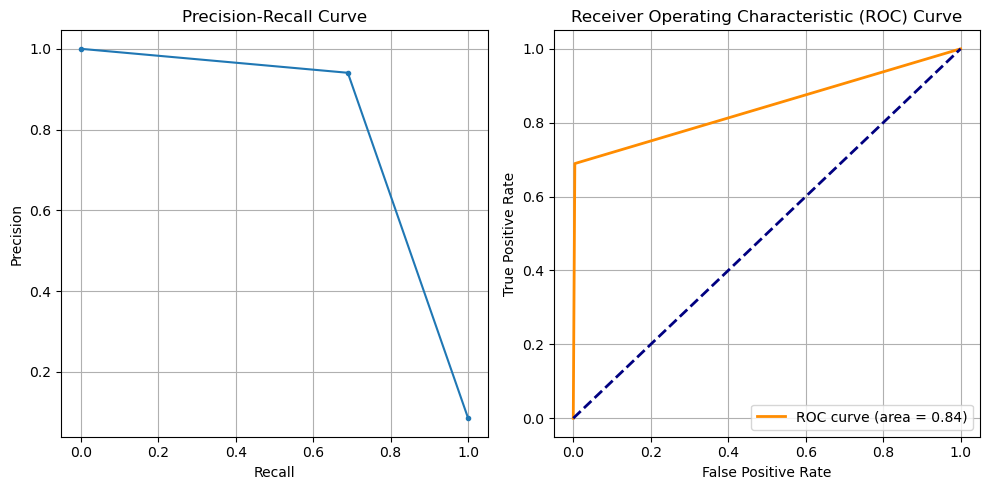

In [54]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].plot(recall,precision,marker='.')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].grid(True)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True)
plt.tight_layout()
plt.show()